## General stuff
Guassian:\
$\phi(x) = e^{-\|x\|^2}$

Image function:\
$ f : \mathbb{R}^2 \to \mathbb{R}$

Approximation:\
$ \hat{f}(x) = \sum^n_{i=0}\alpha_i (g_i \triangleright \phi)(y) = \sum^n_{i=0}\alpha_i (\psi(v_i) \triangleright \phi)(y)$

Lie group (dim 6):\
$G = \text{Aff}^+(2)$

Group action on $R^2$:\
For $g \in G, y \in R^2$ then $g \triangleright y = (x, A) \triangleright y := Ay + x$

For $f : \mathbb{R}^2 \to \mathbb{R}$ then $(g \triangleright f)(y) := f(g^{-1} \triangleright y)$ 

Parameter space (dim 6):\
$V = \mathbb{R}^2 \times \text{SO}(2) \times \text{SNM}(2)$

Mapping:\
$\psi : V \to G$\
$\psi(L, X, Y) = (L, \exp(X)\exp(Y))$

For $X = \begin{pmatrix}
0 & b \\
-b & 0
\end{pmatrix}$ then $\exp(X) = \begin{pmatrix}
\cos(b) & \sin(b) \\
-\sin(b) & \cos(b)
\end{pmatrix}$

For
$
Y=\begin{pmatrix}a & b \\ b & c\end{pmatrix},
$
define
$
m=\tfrac{a+c}{2}, \quad 
B = Y - mI = \begin{pmatrix}\tfrac{a-c}{2} & b \\[4pt] b & -\tfrac{a-c}{2}\end{pmatrix}, \quad 
s=\sqrt{b^{2}+\left(\tfrac{a-c}{2}\right)^{2}}.
$

Then
$
\exp(Y) \;=\; e^{\,m}\!\left( \cosh(s)\,I + \frac{\sinh(s)}{s}\,B \right).
$

Loss:\
$\mathcal{L} = \|f-\hat{f}\|_{L^2}$

In [1]:
import torch
import numpy as np
import math

In [2]:
# Group actions

def group_action(x: torch.Tensor, A: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
    return torch.einsum('gjk,gk->gj', A, y) + x

def group_action_inv(x: torch.Tensor, A: torch.Tensor, y: torch.Tensor) -> torch.Tensor:
    return torch.einsum('gjk,gk->gj', torch.linalg.inv(A), y - x)

def group_action_func(x: torch.Tensor, A: torch.Tensor, y: torch.Tensor, f: callable) -> torch.Tensor:
    y_inv = group_action_inv(x, A, y)
    return f(y_inv)

In [3]:
# Mapping from parametric space to lie group

# Map exp of the theta of a 2x2 anti symmetric matrix to explicit
def exp_SO(theta: torch.Tensor) -> torch.Tensor:
    return torch.stack([torch.stack([torch.cos(theta), -torch.sin(theta)]),
                         torch.stack([torch.sin(theta), torch.cos(theta)])]).permute(2, 0, 1)

# Map exp of 2x2 symmetric matrix to explicit
def exp_SNM(a: torch.Tensor, b: torch.Tensor, c: torch.Tensor) -> torch.Tensor:
    m = 0.5 * (a + c)

    # Define B = A - mI
    B00 = 0.5 * (a - c)
    B01 = b
    B10 = b
    B11 = -0.5 * (a - c)

    # Compute s = sqrt(b^2 + ((a-c)/2)^2)
    s = torch.sqrt(b**2 + (0.5 * (a - c))**2)

    # Handle s=0 case with safe division
    sinhc = torch.where(s > 1e-12, torch.sinh(s) / s, torch.ones_like(s))

    # exp(A) = exp(m) * (cosh(s) * I + (sinh(s)/s) * B)
    expm = torch.zeros(m.shape + (2, 2), dtype=m.dtype, device=a.device)
    expm[..., 0, 0] = torch.cosh(s) + sinhc * B00
    expm[..., 0, 1] = sinhc * B01
    expm[..., 1, 0] = sinhc * B10
    expm[..., 1, 1] = torch.cosh(s) + sinhc * B11

    return torch.exp(m)[..., None, None] * expm




In [22]:
# gaussian

def gaussian(y: torch.Tensor):
    norm = torch.linalg.vector_norm(y, dim=-1)
    return torch.exp(-1 * torch.pow(norm, 2))

def f_hat(w: torch.Tensor, width: int, height: int, normalize_only_alpha: bool) -> torch.Tensor:
    """
    Calculate f_hat with w for the grid width to height
    """
    # calc all parameters
    alpha = w[0]
    a = w[1]
    b = w[2]
    c = w[3]
    theta = w[4]
    x1 = w[5]
    x2 = w[6]

    Y = exp_SNM(a, b, c)

    A = exp_SO(theta) @ Y
    x = torch.stack([x1, x2]).permute(1, 0)

    sampling_grid = torch.nn.functional.affine_grid(torch.cat([torch.linalg.inv(A), (x*-1).unsqueeze(-1)], dim=-1), torch.Size((A.size()[0], 1, height, width)))

    norm = torch.linalg.vector_norm(sampling_grid, dim=-1)
    if normalize_only_alpha:
        return (torch.sigmoid(alpha).unsqueeze(-1).unsqueeze(-1) * torch.exp(-1 * torch.pow(norm, 2))).sum(dim=0)
    else:
        return torch.sigmoid((alpha.unsqueeze(-1).unsqueeze(-1) * torch.exp(-1 * torch.pow(norm, 2))).sum(dim=0))



In [ ]:

torch.autograd.set_detect_anomaly(False)

device = torch.device("cuda:0")

def train(learning_rate: float, iterations: int, guassians: int, target: torch.Tensor, normalize_only_alpha: bool):

   

    w = torch.nn.Parameter(torch.randn(7, guassians, device=device))
    # w[0] = alpha
    # w[1] = a
    # w[2] = b
    # w[3] = c
    # w[4] = theta
    # w[5] = x1
    # w[6] = x2

    optimizer = torch.optim.AdamW(
        [w],
        lr=learning_rate,
        weight_decay=1e-1,
    )

    for iteration in range(iterations):
            
        preds = f_hat(w, target.size()[0], target.size()[1], normalize_only_alpha)

        loss = ((target - preds)**2).mean()

        if (iteration + 1) % (iterations/10) == 0:
            print(f"Iteration {iteration+1}/{iterations}")
            print(f"Loss: {loss.item():0.5f}")


        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

    preds = f_hat(w, target.size()[0], target.size()[1], normalize_only_alpha)
    loss = ((target - preds)**2).mean()

    return loss, w

In [6]:
import torchvision

def img_to_tensor(img_path: str) -> torch.Tensor:
    return torchvision.io.read_image(img_path)

In [7]:
import matplotlib.pyplot as plt
# plot 2D image of gaussian function
def plot_image(w: torch.Tensor, resolution, normalize_only_alpha: bool):
    w = w.detach().cpu()
    plt.title("2D Gaussian")
    plt.imshow(f_hat(w, resolution, resolution, normalize_only_alpha), origin='upper', cmap='gray', vmin=0, vmax=1)
    plt.show()

In [10]:
learning_rate = 0.001
epochs = 100

# create a 4x4 tensor with all the same value a=0.3
a = 0.5
output_z = torch.full((100, 100), a, device=device)

loss, w = train(learning_rate, epochs, 1, output_z)
print(w, loss)


/var/home/victor/Code/bep/.venv/lib64/python3.13/site-packages/torch/nn/functional.py:5163: UserWarning: Default grid_sample and affine_grid behavior has changed to align_corners=False since 1.3.0. Please specify align_corners=True if the old behavior is desired. See the documentation of grid_sample for details.
  warnings.warn(


Parameter containing:
tensor([[-0.6666],
        [-0.4782],
        [-0.0394],
        [ 1.4393],
        [ 0.6271],
        [ 0.1429],
        [-0.1876]], device='cuda:0', requires_grad=True) tensor(0.1107, device='cuda:0', grad_fn=<MeanBackward0>)


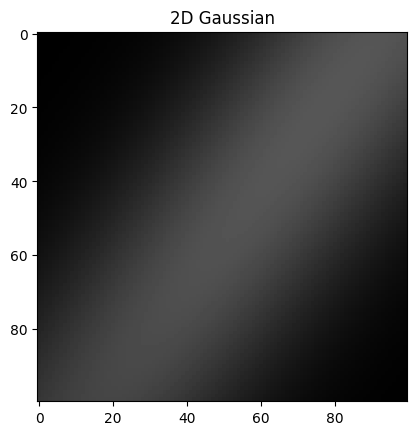

In [11]:
plot_image(w, 100)

In [12]:
learning_rate = 0.1
iterations = 500
guassians = 100

# create a 5x5 with a black stripe in the middle
output_z = torch.cat([torch.full((40, 100), 0), torch.full((20, 100), 1), torch.full((40, 100), 0)]).to(device)

loss, w = train(learning_rate, iterations, guassians, output_z)

print(loss)

tensor(0.0144, device='cuda:0', grad_fn=<MeanBackward0>)


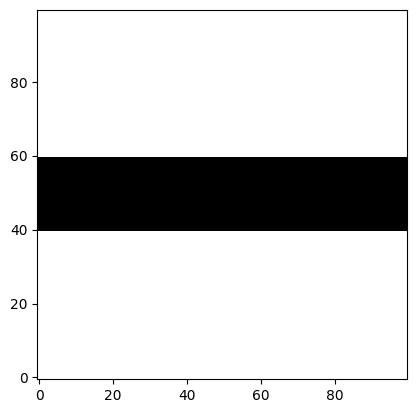

In [13]:
plt.imshow(1 - output_z.cpu(), origin='lower', cmap='gray', vmin=0, vmax=1)
plt.show()

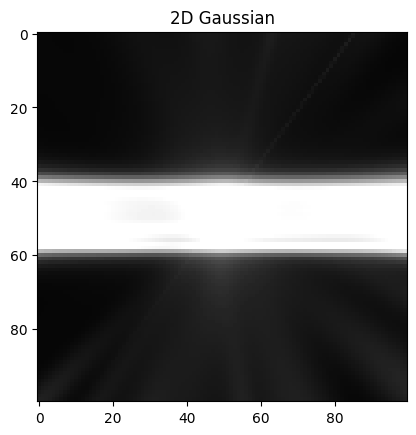

In [14]:
plot_image(w, 100)

In [15]:
learning_rate = 0.1
iterations = 500
guassians = 100

# create a 5x5 with a black stripe in the middle
output_z = torch.cat([torch.full((50, 100), 0), torch.full((50, 100), 1)]).to(device)

loss, w = train(learning_rate, iterations, guassians, output_z)

print(loss)

tensor(0.0111, device='cuda:0', grad_fn=<MeanBackward0>)


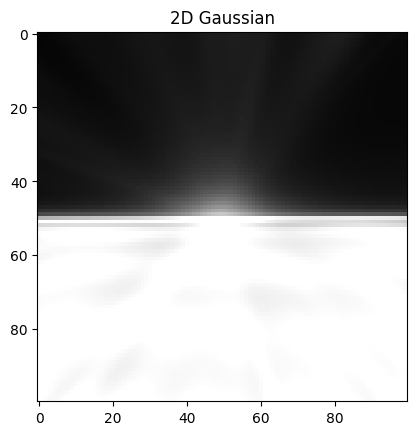

In [16]:
plot_image(w, 100)

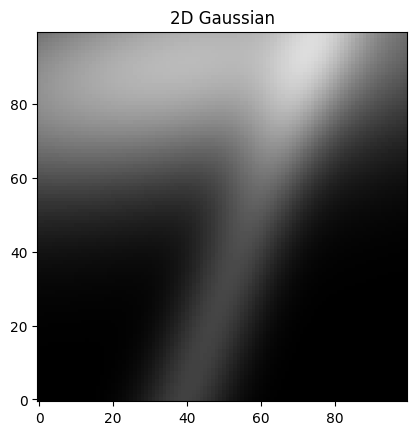

In [17]:
w = torch.tensor([[-1,  0, -1.5, 0,  2, -0.5,  -0.5], [1,  0, -0.5, 0,  1, 1,  1]]).permute(1, 0)

plt.title("2D Gaussian")
plt.imshow(f_hat(w, 100, 100), origin='lower', cmap='gray', vmin=0, vmax=1)
plt.show()

torch.Size([1])
torch.Size([1, 2, 2])
torch.Size([1, 2])
tensor([0.1213])


/tmp/ipykernel_8248/1684412750.py:16: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /pytorch/torch/csrc/utils/tensor_new.cpp:253.)
  print(group_action_func(x, exp_SO(theta) @ exp_SNM(a,b,c), torch.tensor([points[0, 0]], dtype=torch.float), gaussian))


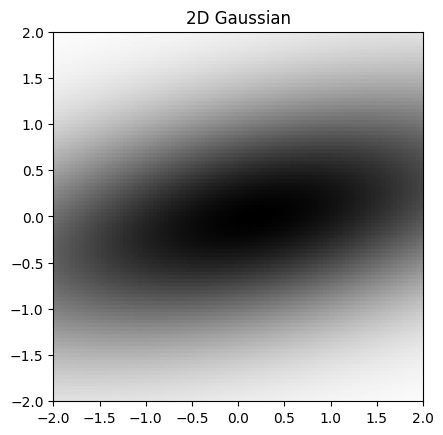

In [18]:
# Create a grid of points
xv, yv = np.meshgrid(np.linspace(-1, 1, 100), np.linspace(-1, 1, 100))
points = np.stack([xv, yv], axis=-1)  # shape (100, 100, 2)

x = torch.tensor([[0.1,0]])
# 1.1102,  0.7595, -0.3787, -1.3284,  0.3944, -0.2805,  1.2112

a = torch.tensor([0])
b = torch.tensor([-0.5])
c = torch.tensor([0])
print(c.size())
theta = torch.tensor([1])
print((exp_SO(theta) @ exp_SNM(a,b,c)).size())
print(x.size())

print(group_action_func(x, exp_SO(theta) @ exp_SNM(a,b,c), torch.tensor([points[0, 0]], dtype=torch.float), gaussian))


# Evaluate gaussian at each point
gauss_img = np.zeros((100, 100))
for i in range(100):
	for j in range(100):
		gauss_img[i, j] = torch.sigmoid(torch.tensor(100))*group_action_func(x, exp_SO(theta) @ exp_SNM(a,b,c), torch.tensor([points[i, j]], dtype=torch.float), gaussian).sum()

plt.title("2D Gaussian")
plt.imshow(1 - gauss_img, extent=[-2, 2, -2, 2], origin='lower', cmap='gray', vmin=0, vmax=1)
plt.show()

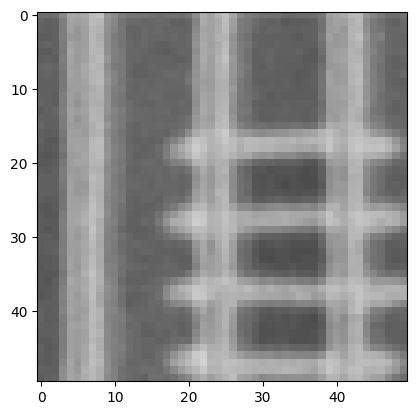

In [8]:
img = torchvision.transforms.functional.crop(torchvision.io.decode_image('./data/sem-railroad.png').float(), 0, 0, 450, 450)

plt.imshow(torchvision.transforms.Resize(50)(img).mean(0), origin='upper', cmap='gray', vmin=0, vmax=255)

In [9]:
learning_rate = 0.1
iterations = 5000
guassians = 50

output_z = torchvision.transforms.Resize(50)(img).mean(0).to(device) / 255.0
loss, w = train(learning_rate, iterations, guassians, output_z, False)

print(loss)

/var/home/victor/Code/bep/.venv/lib64/python3.13/site-packages/torch/nn/functional.py:5163: UserWarning: Default grid_sample and affine_grid behavior has changed to align_corners=False since 1.3.0. Please specify align_corners=True if the old behavior is desired. See the documentation of grid_sample for details.
  warnings.warn(


Iteration 500/5000
Loss: 0.20112
Iteration 1000/5000
Loss: 0.11471
Iteration 1500/5000
Loss: 0.07681
Iteration 2000/5000
Loss: 0.05560
Iteration 2500/5000
Loss: 0.04265
Iteration 3000/5000
Loss: 0.03434
Iteration 3500/5000
Loss: 0.02889
Iteration 4000/5000
Loss: 0.02529
Iteration 4500/5000
Loss: 0.02289
Iteration 5000/5000
Loss: 0.02130
tensor(0.0213, device='cuda:0', grad_fn=<MeanBackward0>)


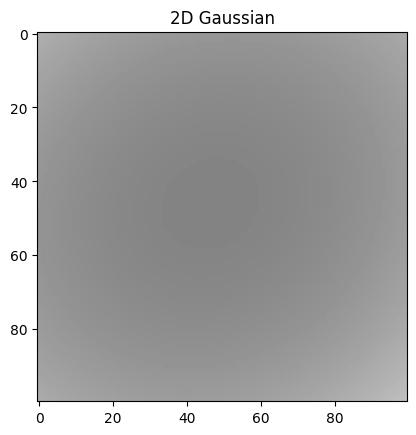

In [11]:
plot_image(w, 100, False)

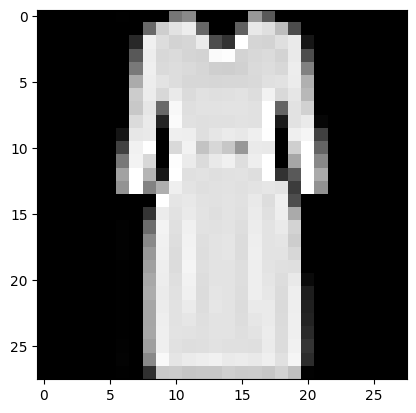

In [12]:
img = torchvision.io.decode_image('./data/fashionmnist-val-1022.png')[0]

plt.imshow(img, origin='upper', cmap='gray', vmin=0, vmax=255)
plt.show()

In [14]:
img = torchvision.io.decode_image('./data/fashionmnist-val-1022.png')[0]

print(img.size())

learning_rate = 0.1
iterations = 5000
guassians = 50
# create a 5x5 with a black stripe in the middle
output_z = img.to(device) / 255.0

loss, w = train(learning_rate, iterations, guassians, output_z, True)

print(loss)

torch.Size([28, 28])
Iteration 500/5000
Loss: 0.02104
Iteration 1000/5000
Loss: 0.01611
Iteration 1500/5000
Loss: 0.01232
Iteration 2000/5000
Loss: 0.01002
Iteration 2500/5000
Loss: 0.00893
Iteration 3000/5000
Loss: 0.00808
Iteration 3500/5000
Loss: 0.00780
Iteration 4000/5000
Loss: 0.00755
Iteration 4500/5000
Loss: 0.00724
Iteration 5000/5000
Loss: 0.00698
tensor(0.0070, device='cuda:0', grad_fn=<MeanBackward0>)


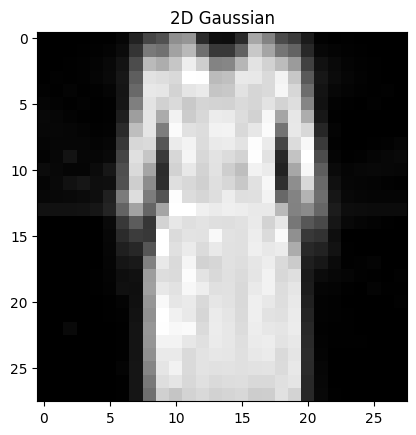

In [15]:
plot_image(w, 28, True)

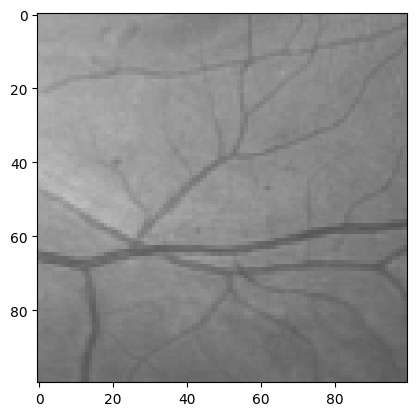

In [16]:
img = torchvision.transforms.functional.crop(torchvision.io.decode_image('./data/retinal-vessels.jpg'), 0, 0, 230, 230).float()
img = torchvision.transforms.Resize(100)(img).mean(0)

plt.imshow(img, origin='upper', cmap='gray', vmin=0, vmax=255)

In [ ]:
img = torchvision.transforms.functional.crop(torchvision.io.decode_image('./data/retinal-vessels.jpg'), 0, 0, 230, 230).float()

print(img.size())

learning_rate = 0.01
iterations = 5000
guassians = 500

# create a 5x5 with a black stripe in the middle
output_z = torchvision.transforms.Resize(100)(img).mean(0).to(device) / 255.0
print(output_z)

loss, w = train(learning_rate, iterations, guassians, output_z, False)

print(loss)

torch.Size([3, 230, 230])
tensor([[0.6418, 0.6354, 0.6427,  ..., 0.5251, 0.4962, 0.4947],
        [0.6426, 0.6374, 0.6401,  ..., 0.5371, 0.5077, 0.5108],
        [0.6358, 0.6498, 0.6474,  ..., 0.5371, 0.5095, 0.4926],
        ...,
        [0.4490, 0.4485, 0.4494,  ..., 0.3680, 0.3755, 0.3781],
        [0.4342, 0.4456, 0.4580,  ..., 0.3673, 0.3763, 0.3826],
        [0.4288, 0.4387, 0.4457,  ..., 0.3817, 0.3726, 0.3711]],
       device='cuda:0')
Iteration 500/5000
Loss: 0.00066
Iteration 1000/5000
Loss: 0.00398
Iteration 1500/5000
Loss: 0.00191
Iteration 2000/5000
Loss: 0.00091
Iteration 2500/5000
Loss: 0.00184
Iteration 3000/5000
Loss: 0.00204
Iteration 3500/5000
Loss: 0.00167
Iteration 4000/5000
Loss: 0.00200
Iteration 4500/5000
Loss: 0.00207
Iteration 5000/5000
Loss: 0.00142
tensor(0.0017, device='cuda:0', grad_fn=<MeanBackward0>)


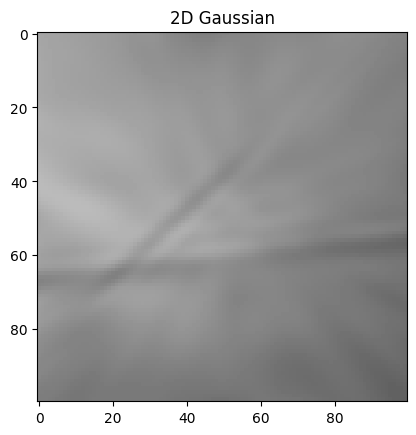

In [38]:
plot_image(w, 100, False)